<a href="https://colab.research.google.com/github/Kai-LiC/Biostat_IGL_project/blob/main/traces__for_fens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


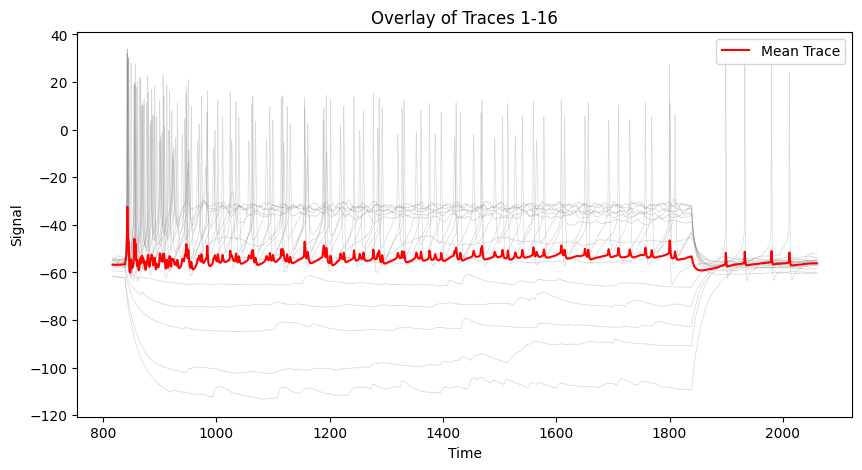

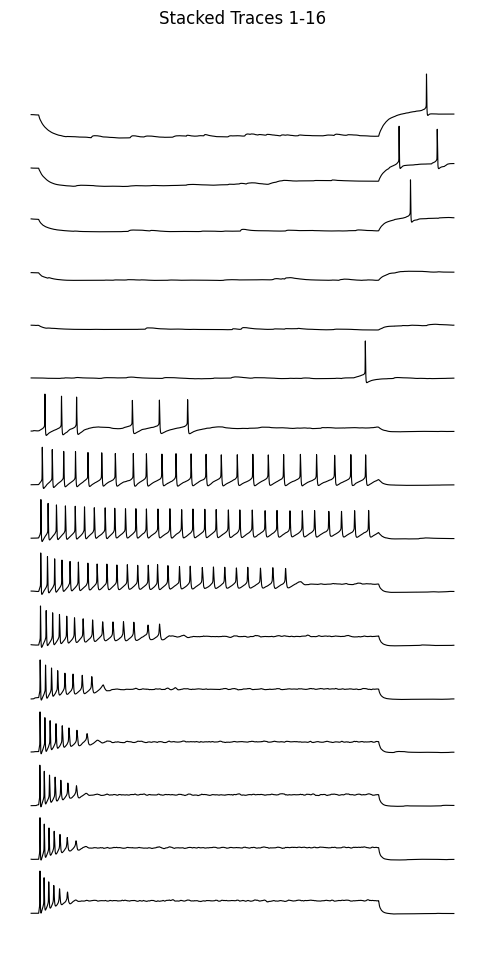

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取 Excel 檔案 (不設 header，完全交由後面手動解析)
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列 (避開頂部的 Clampfit 文字標題)
start_row = 0
for i in range(len(df)):
    # 嘗試將第一欄的內容轉成數字，如果成功，代表這列開始是真正的數據
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
# 第一欄為時間，後面 16 欄為 Trace 1 到 16
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 圖一：疊加圖 (Overlay Plot) - 適合看整體變化與平均趨勢
# ====================================================
plt.figure(figsize=(10, 5))
for col in traces.columns:
    plt.plot(time, traces[col], color='gray', alpha=0.3, linewidth=0.5)

# 畫出紅色平均線
plt.plot(time, traces.mean(axis=1), color='red', linewidth=1.5, label='Mean Trace')

plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Overlay of Traces 1-16')
plt.legend(loc='upper right')
plt.grid(False)
plt.show()

# ====================================================
# 圖二：垂直排列圖 (Stacked Plot) - 論文標準瀑布圖
# ====================================================
plt.figure(figsize=(6, 12))

# 💡 請根據你數據的振幅調整這個 offset！
# 如果線全部疊在一起，就把這個值改大（例如 100, 500 或 1000）
# 如果線隔得太遠，就把這個值改小（例如 10 或 20）
mx_val = traces.max().max()
mn_val = traces.min().min()
offset = (mx_val - mn_val) * 0.8  # 自動根據振幅估計一個初始隔開距離

for i, col in enumerate(traces.columns):
    plt.plot(time, traces[col] - (i * offset), color='black', linewidth=0.8)

plt.axis('off')  # 隱藏外框與座標軸，符合電生理論文標準外觀
plt.title('Stacked Traces 1-16')
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


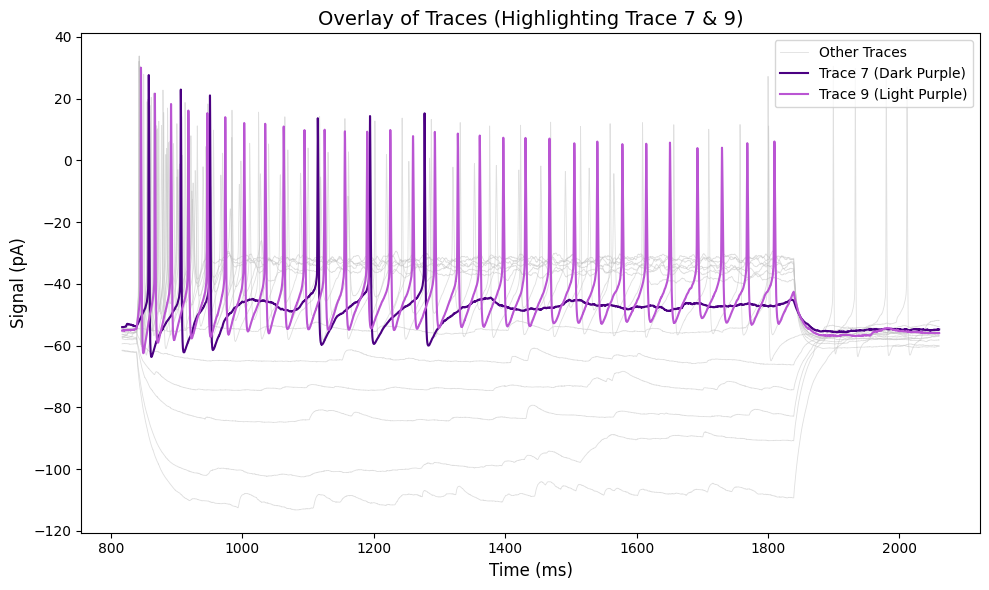

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 參數設定（可根據實際實驗手動修改單位）
# ==========================================
X_UNIT = "ms"      # 時間單位，例如: ms 或 s
Y_UNIT = "pA"      # 訊號單位，例如: pA, nA 或 mV

# 1. 讀取 Excel 檔案 (不設 header，完全交由後面手動解析)
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列 (避開頂部的 Clampfit 文字標題)
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：所有 Traces 疊加圖 (特定 Trace 著色版)
# ====================================================
plt.figure(figsize=(10, 6))

# 這裡因為 Python 索引從 0 開始，所以：
# df 的第 1 欄數據對應到實際的 Trace 1
# df 的第 7 欄數據對應到實際的 Trace 7
# df 的第 9 欄數據對應到實際的 Trace 9
# 我們直接用 `traces.columns[i]` 來對應第幾條線

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 7:
        # Trace 7: 深紫色，線條加粗，zorder=3 確保在最上層
        plt.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, label='Trace 7 (Dark Purple)', zorder=3)
    elif trace_num == 9:
        # Trace 9: 淺紫色，線條加粗，zorder=3 確保在最上層
        plt.plot(time, traces[col], color='#BA55D3', alpha=1.0, linewidth=1.5, label='Trace 9 (Light Purple)', zorder=3)
    else:
        # 其他 Trace: 灰色背景，zorder=2
        # 只幫第一個灰色 trace 加 label，避免 legend 重複出現一堆 "Other Traces"
        label_text = 'Other Traces' if trace_num == 1 else ""
        plt.plot(time, traces[col], color='#C0C0C0', alpha=0.5, linewidth=0.6, label=label_text, zorder=2)

# 設定標籤與手動加入單位
plt.xlabel(f'Time ({X_UNIT})', fontsize=12)
plt.ylabel(f'Signal ({Y_UNIT})', fontsize=12)
plt.title('Overlay of Traces (Highlighting Trace 7 & 9)', fontsize=14)

# 顯示圖例
plt.legend(loc='upper right', frameon=True)
plt.grid(False) # 電生理圖通常習慣不留格子，若需要可改為 True

plt.tight_layout()
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


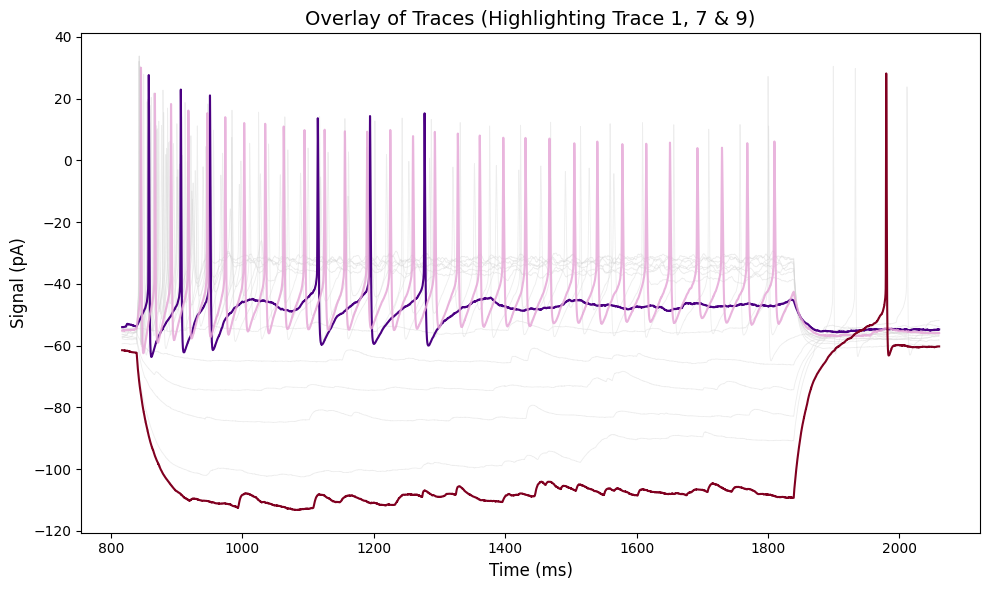

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 參數設定（可根據實際實驗手動修改單位）
# ==========================================
X_UNIT = "ms"      # 時間單位
Y_UNIT = "pA"      # 訊號單位

# 1. 讀取 Excel 檔案
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：所有 Traces 疊加圖 (特定顏色高亮版)
# ====================================================
plt.figure(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 深酒紅色，突顯 Rebound Spike，放最上層 (zorder=4)
        plt.plot(time, traces[col], color='#800020', alpha=1.0, linewidth=1.5, zorder=4)

    elif trace_num == 7:
        # Trace 7: 深紫色，放上層 (zorder=3)
        plt.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, zorder=3)

    elif trace_num == 9:
        # Trace 9: 修改為更淺的粉紫/薰衣草紫，適度調低透明度以免太刺眼
        plt.plot(time, traces[col], color='#E6A8D7', alpha=0.85, linewidth=1.5, zorder=3)

    else:
        # 其他 Trace: 保持淡灰色作為背景襯托 (zorder=2)
        plt.plot(time, traces[col], color='#D3D3D3', alpha=0.4, linewidth=0.6, zorder=2)

# 設定標籤與加入單位
plt.xlabel(f'Time ({X_UNIT})', fontsize=12)
plt.ylabel(f'Signal ({Y_UNIT})', fontsize=12)
plt.title('Overlay of Traces (Highlighting Trace 1, 7 & 9)', fontsize=14)

# 依據你的要求：不顯示圖例 (沒有 plt.legend)
plt.grid(False)

plt.tight_layout()
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


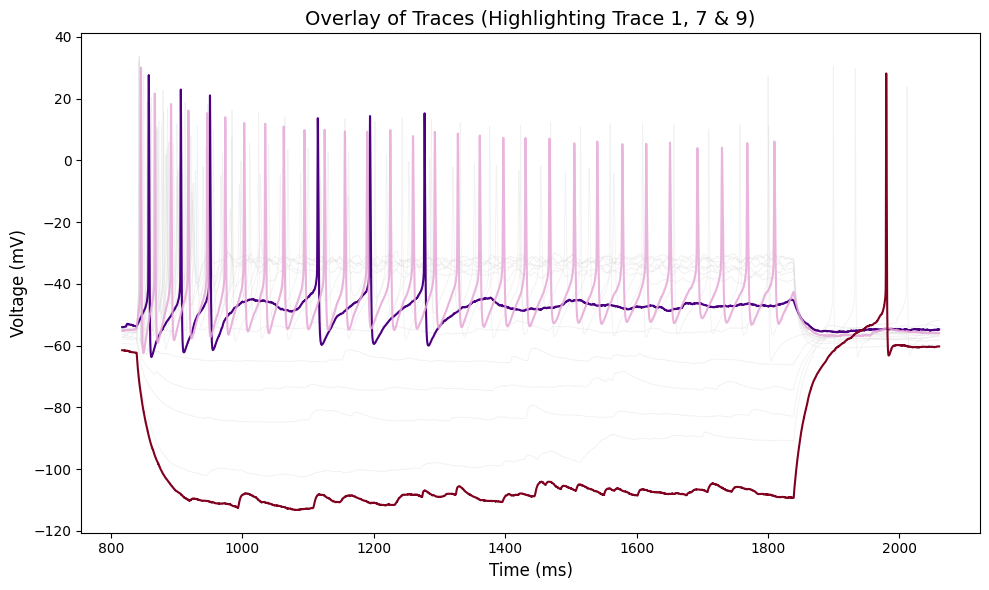

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 參數設定（已修正為 Current Clamp 單位）
# ==========================================
X_UNIT = "ms"      # 時間單位
Y_UNIT = "mV"      # 訊號單位 (Current Clamp 模式下為 mV)

# 1. 讀取 Excel 檔案
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：所有 Traces 疊加圖 (Current Clamp 修正版)
# ====================================================
plt.figure(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 深酒紅色，突顯 Rebound Spike，最上層 (zorder=4)
        plt.plot(time, traces[col], color='#800020', alpha=1.0, linewidth=1.5, zorder=4)

    elif trace_num == 7:
        # Trace 7: 深紫色，放上層 (zorder=3)
        plt.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, zorder=3)

    elif trace_num == 9:
        # Trace 9: 淺粉紫/薰衣草紫，適度調低透明度以免太刺眼 (zorder=3)
        plt.plot(time, traces[col], color='#E6A8D7', alpha=0.85, linewidth=1.5, zorder=3)

    else:
        # 其他 Trace: 保持淡灰色作為背景襯托，透明度稍微調低讓主線更明顯 (zorder=2)
        plt.plot(time, traces[col], color='#D3D3D3', alpha=0.3, linewidth=0.6, zorder=2)

# 設定標籤與加入單位 (自動帶入 mV)
plt.xlabel(f'Time ({X_UNIT})', fontsize=12)
plt.ylabel(f'Voltage ({Y_UNIT})', fontsize=12)
plt.title('Overlay of Traces (Highlighting Trace 1, 7 & 9)', fontsize=14)

# 不顯示圖例
plt.grid(False)

plt.tight_layout()
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


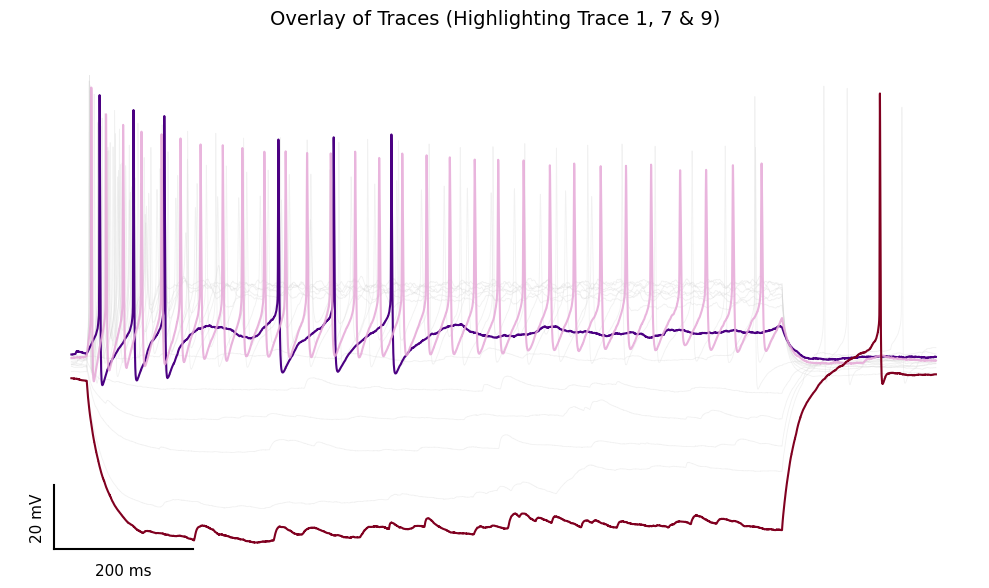

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 比例尺與單位參數設定
# ==========================================
SCALE_X_LEN = 200    # X軸比例尺長度 (ms)
SCALE_Y_LEN = 20     # Y軸比例尺長度 (mV)
X_UNIT = "ms"
Y_UNIT = "mV"

# 1. 讀取 Excel 檔案
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：隱藏傳統 X/Y 軸，改用 L 型比例尺
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 深酒紅色，突顯 Rebound Spike
        ax.plot(time, traces[col], color='#800020', alpha=1.0, linewidth=1.5, zorder=4)
    elif trace_num == 7:
        # Trace 7: 深紫色
        ax.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, zorder=3)
    elif trace_num == 9:
        # Trace 9: 新版淺粉紫/薰衣草紫
        ax.plot(time, traces[col], color='#E6A8D7', alpha=0.85, linewidth=1.5, zorder=3)
    else:
        # 其他 Trace: 淡灰色背景
        ax.plot(time, traces[col], color='#D3D3D3', alpha=0.3, linewidth=0.6, zorder=2)

# ----------------------------------------------------
# 💡 核心：關閉傳統座標軸，手動繪製 L 型比例尺
# ----------------------------------------------------
ax.axis('off')  # 拔掉所有外框、刻度、與標籤

# 計算比例尺的最佳擺放位置 (取數據的左下角再往外挪一點點)
data_x_min, data_x_max = time.min(), time.max()
data_y_min, data_y_max = traces.min().min(), traces.max().max()

# 比例尺的原點 (L型的轉角處)
scale_origin_x = data_x_min - (data_x_max - data_x_min) * 0.02
scale_origin_y = data_y_min - 2  # 往下移 2 mV 避免與數據重疊

# 畫 L 型比例尺的線條
# Y軸垂直線 (電壓)
ax.plot([scale_origin_x, scale_origin_x], [scale_origin_y, scale_origin_y + SCALE_Y_LEN], color='black', linewidth=1.5, solid_capstyle='projecting')
# X軸水平線 (時間)
ax.plot([scale_origin_x, scale_origin_x + SCALE_X_LEN], [scale_origin_y, scale_origin_y], color='black', linewidth=1.5, solid_capstyle='projecting')

# 加上比例尺的文字標籤
ax.text(scale_origin_x - (data_x_max - data_x_min) * 0.01, scale_origin_y + SCALE_Y_LEN / 2,
        f'{SCALE_Y_LEN} {Y_UNIT}', va='center', ha='right', fontsize=11, rotation=90)
ax.text(scale_origin_x + SCALE_X_LEN / 2, scale_origin_y - (data_y_max - data_y_min) * 0.03,
        f'{SCALE_X_LEN} {X_UNIT}', va='top', ha='center', fontsize=11)

# 設定標題與緊湊排版
ax.set_title('Overlay of Traces (Highlighting Trace 1, 7 & 9)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


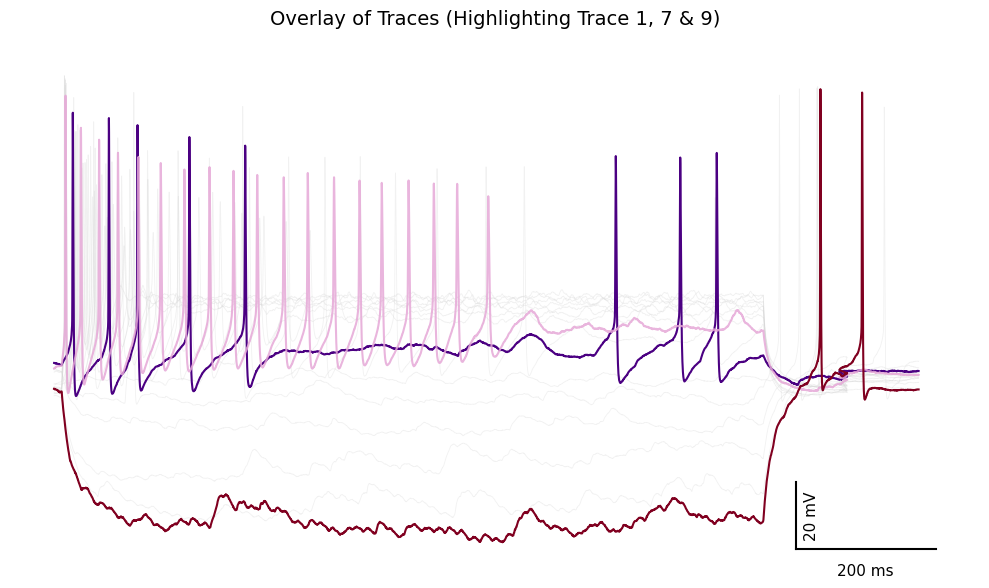

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 比例尺與單位參數設定
# ==========================================
SCALE_X_LEN = 200    # X軸比例尺長度 (ms)
SCALE_Y_LEN = 20     # Y軸比例尺長度 (mV)
X_UNIT = "ms"
Y_UNIT = "mV"

# 1. 讀取 Excel 檔案
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：隱藏傳統 X/Y 軸，改用右下角 L 型比例尺
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 深酒紅色，突顯 Rebound Spike
        ax.plot(time, traces[col], color='#800020', alpha=1.0, linewidth=1.5, zorder=4)
    elif trace_num == 7:
        # Trace 7: 深紫色
        ax.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, zorder=3)
    elif trace_num == 9:
        # Trace 9: 淺粉紫/薰衣草紫
        ax.plot(time, traces[col], color='#E6A8D7', alpha=0.85, linewidth=1.5, zorder=3)
    else:
        # 其他 Trace: 淡灰色背景
        ax.plot(time, traces[col], color='#D3D3D3', alpha=0.3, linewidth=0.6, zorder=2)

# ----------------------------------------------------
# 💡 核心：關閉傳統座標軸，在右下角繪製 L 型比例尺
# ----------------------------------------------------
ax.axis('off')  # 拔掉所有外框、刻度與標籤

# 取得數據的最大、最小值來決定比例尺邊界
data_x_min, data_x_max = time.min(), time.max()
data_y_min, data_y_max = traces.min().min(), traces.max().max()

# 比例尺的原點 (將其定在右下角，並留一點微小的邊距邊緣)
scale_origin_x = data_x_max - SCALE_X_LEN + (data_x_max - data_x_min) * 0.02
scale_origin_y = data_y_min - 2  # 稍微往下挪一點，避免壓到最底部的線

# 畫 L 型比例尺的線條 (在右下角相交於原點)
# Y軸垂直線 (電壓)
ax.plot([scale_origin_x, scale_origin_x], [scale_origin_y, scale_origin_y + SCALE_Y_LEN], color='black', linewidth=1.5, solid_capstyle='projecting')
# X軸水平線 (時間)
ax.plot([scale_origin_x, scale_origin_x + SCALE_X_LEN], [scale_origin_y, scale_origin_y], color='black', linewidth=1.5, solid_capstyle='projecting')

# 加上比例尺的文字標籤
# Y軸單位：放在垂直線的右側 (ha='left')
ax.text(scale_origin_x + (data_x_max - data_x_min) * 0.01, scale_origin_y + SCALE_Y_LEN / 2,
        f'{SCALE_Y_LEN} {Y_UNIT}', va='center', ha='left', fontsize=11, rotation=90)
# X軸單位：放在水平線下方置中 (ha='center')
ax.text(scale_origin_x + SCALE_X_LEN / 2, scale_origin_y - (data_y_max - data_y_min) * 0.03,
        f'{SCALE_X_LEN} {X_UNIT}', va='top', ha='center', fontsize=11)

# 設定標題與緊湊排版
ax.set_title('Overlay of Traces (Highlighting Trace 1, 7 & 9)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 31086 筆，成功偵測到 16 條 Traces。


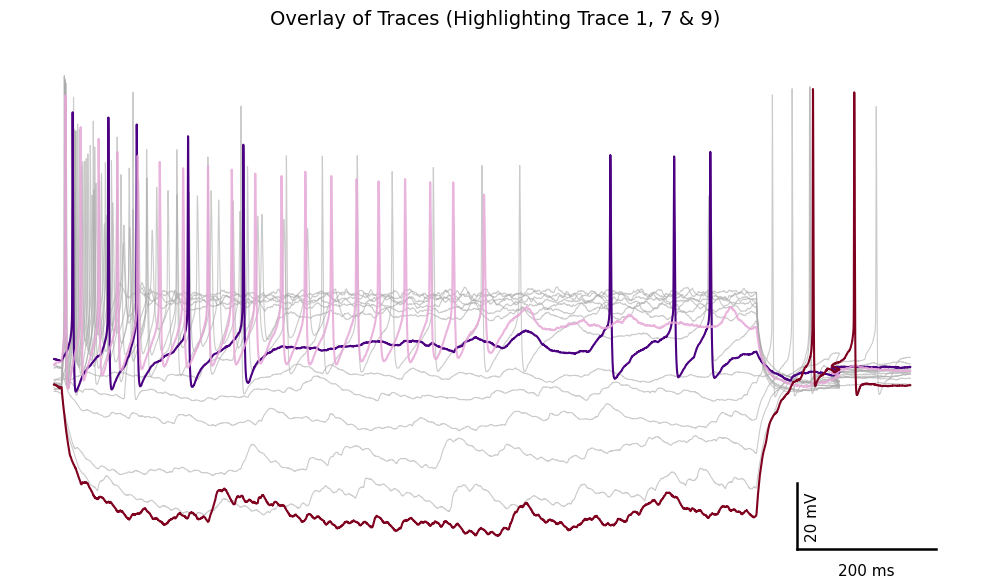

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 比例尺與單位參數設定
# ==========================================
SCALE_X_LEN = 200    # X軸比例尺長度 (ms)
SCALE_Y_LEN = 20     # Y軸比例尺長度 (mV)
X_UNIT = "ms"
Y_UNIT = "mV"

# 1. 讀取 Excel 檔案
file_path = "4531_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：隱藏傳統 X/Y 軸，改用右下角 L 型比例尺 (背景加深版)
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 深酒紅色，突顯 Rebound Spike
        ax.plot(time, traces[col], color='#800020', alpha=1.0, linewidth=1.5, zorder=4)
    elif trace_num == 7:
        # Trace 7: 深紫色
        ax.plot(time, traces[col], color='#4B0082', alpha=1.0, linewidth=1.5, zorder=3)
    elif trace_num == 9:
        # Trace 9: 淺粉紫/薰衣草紫
        ax.plot(time, traces[col], color='#E6A8D7', alpha=0.85, linewidth=1.5, zorder=3)
    else:
        # 其他 Trace: 修正為較深的中灰色 (#A9A9A9)，提高透明度 (alpha=0.6) 與線寬 (linewidth=0.8)
        ax.plot(time, traces[col], color='#A9A9A9', alpha=0.6, linewidth=0.8, zorder=2)

# ----------------------------------------------------
# 💡 核心：關閉傳統座標軸，在右下角繪製 L 型比例尺
# ----------------------------------------------------
ax.axis('off')  # 拔掉所有外框、刻度與標籤

# 取得數據的最大、最小值來決定比例尺邊界
data_x_min, data_x_max = time.min(), time.max()
data_y_min, data_y_max = traces.min().min(), traces.max().max()

# 比例尺的原點 (定在右下角，並適度挪動避免被加深的灰線遮擋)
scale_origin_x = data_x_max - SCALE_X_LEN + (data_x_max - data_x_min) * 0.03
scale_origin_y = data_y_min - 4  # 稍微再往下移一些

# 畫 L 型比例尺的線條
# Y軸垂直線 (電壓)
ax.plot([scale_origin_x, scale_origin_x], [scale_origin_y, scale_origin_y + SCALE_Y_LEN], color='black', linewidth=1.8, solid_capstyle='projecting', zorder=5)
# X軸水平線 (時間)
ax.plot([scale_origin_x, scale_origin_x + SCALE_X_LEN], [scale_origin_y, scale_origin_y], color='black', linewidth=1.8, solid_capstyle='projecting', zorder=5)

# 加上比例尺的文字標籤 (zorder=5 確保文字在最上層)
# Y軸單位：放在垂直線的右側
ax.text(scale_origin_x + (data_x_max - data_x_min) * 0.01, scale_origin_y + SCALE_Y_LEN / 2,
        f'{SCALE_Y_LEN} {Y_UNIT}', va='center', ha='left', fontsize=11, rotation=90, zorder=5)
# X軸單位：放在水平線下方置中
ax.text(scale_origin_x + SCALE_X_LEN / 2, scale_origin_y - (data_y_max - data_y_min) * 0.03,
        f'{SCALE_X_LEN} {X_UNIT}', va='top', ha='center', fontsize=11, zorder=5)

# 設定標題與緊湊排版
ax.set_title('Overlay of Traces (Highlighting Trace 1, 7 & 9)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

🎉 藝術品級別的 Phase Plane 圖表已匯出為 'trace7_beautiful_phase_plane.png'！


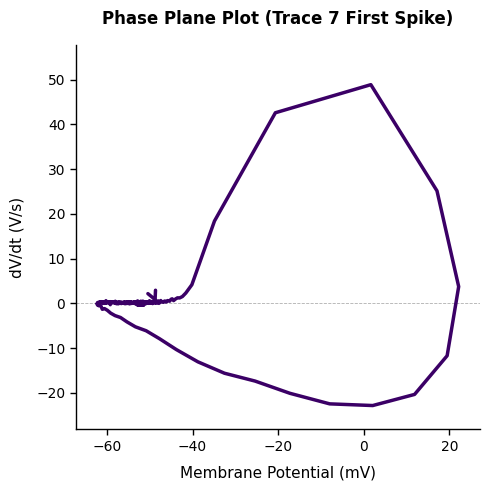

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. 讀取 Phase Plane Plot 專用 Excel 檔案
file_path = "/content/sample_data/4531_PPP.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val_x = float(df.iloc[i, 0])
        val_y = float(df.iloc[i, 1])
        if not np.isnan(val_x) and not np.isnan(val_y):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

# 3. 切割出純數據並轉為 float
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0], clean_data.columns[1]]).reset_index(drop=True)

# 4. 定義原始數據 (確保為 numpy array)
v_raw = clean_data.iloc[:, 0].to_numpy()
dvdt_raw = clean_data.iloc[:, 1].to_numpy()

# ----------------------------------------------------
# 💡 高級美化技巧 1：曲線平滑化 (Smooth Curve)
# ----------------------------------------------------
# 透過參數方程，以點的序號作為自變量進行插值，避免重疊軌跡混亂
t_arr = np.linspace(0, 1, len(v_raw))
t_new = np.linspace(0, 1, 500) # 將數據點擴展至 500 點，極致絲滑

v_smooth = make_interp_spline(t_arr, v_raw, k=3)(t_new)
dvdt_smooth = make_interp_spline(t_arr, dvdt_raw, k=3)(t_new)

# ====================================================
# 繪圖：頂級學術風 Phase Plane Plot
# ====================================================
# 使用正方形比例 (5x5)，這是 Phase Plane 最美觀的形狀
fig, ax = plt.subplots(figsize=(5, 5))

# 畫出極致平滑的相平面軌跡 (改用更有質感的帝王深紫)
ax.plot(v_smooth, dvdt_smooth, color='#3B0066', linewidth=2.5, zorder=3)

# ----------------------------------------------------
# 💡 高級美化技巧 2：在軌跡中間加上順時針方向箭頭
# ----------------------------------------------------
# 尋找去極化上升段的大約中間位置 (dV/dt 最高點附近)
arrow_idx = np.argmax(dvdt_smooth) - 30
ax.annotate('',
            xy=(v_smooth[arrow_idx+1], dvdt_smooth[arrow_idx+1]),
            xytext=(v_smooth[arrow_idx], dvdt_smooth[arrow_idx]),
            arrowprops=dict(arrowstyle="->", color='#3B0066', lw=2.5, mutation_scale=15),
            zorder=4)

# ----------------------------------------------------
# 軸線與刻度高級微調
# ----------------------------------------------------
# 加上 dV/dt = 0 的水平輔助虛線 (顏色調淡，線條變細)
ax.axhline(0, color='#B0B0B0', linestyle='--', linewidth=0.6, zorder=1)

# 設置座標軸標籤與字體
ax.set_xlabel('Membrane Potential (mV)', fontsize=11, fontname='Arial', labelpad=8)
ax.set_ylabel('dV/dt (V/s)', fontsize=11, fontname='Arial', labelpad=8)
ax.set_title('Phase Plane Plot (Trace 7 First Spike)', fontsize=12, fontname='Arial', fontweight='bold', pad=15)

# 限制邊界，讓左右上下的留白更對稱漂亮
ax.set_xlim(v_raw.min() - 5, v_raw.max() + 5)
ax.set_ylim(dvdt_raw.min() - 5, dvdt_raw.max() + 5)

# 只保留左邊和下邊的軸線
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# 讓刻度線朝外 (標準學術標準)
ax.tick_params(direction='out', length=4, width=1.0, labelsize=10)

plt.tight_layout()

# ====================================================
# 💾 匯出頂級畫質圖片
# ====================================================
plt.savefig('trace7_beautiful_phase_plane.png',
            bbox_inches='tight',
            dpi=600,            # 👈 提高到 600 DPI，印刷出版級別超高畫質
            transparent=False,
            facecolor='white')

print("🎉 藝術品級別的 Phase Plane 圖表已匯出為 'trace7_beautiful_phase_plane.png'！")
plt.show()

🎉 經典深紫色、帶點、無網格的 Phase Plane 圖表已成功匯出！


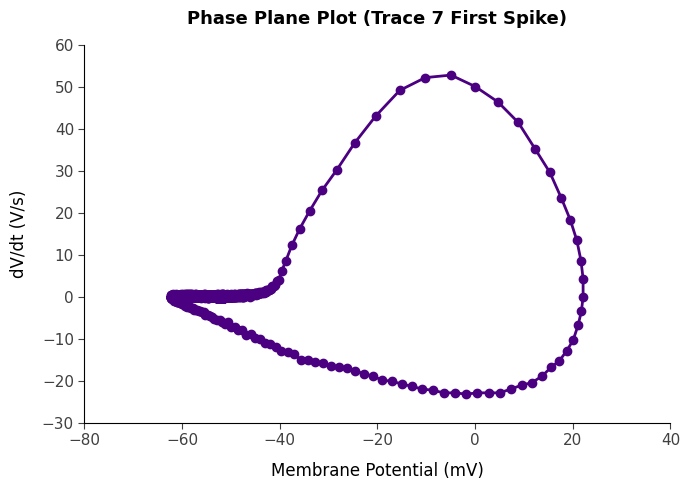

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取 Phase Plane Plot 專用 Excel 檔案
file_path = "/content/sample_data/4531_PPP.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val_x = float(df.iloc[i, 0])
        val_y = float(df.iloc[i, 1])
        if not np.isnan(val_x) and not np.isnan(val_y):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

# 3. 切割出純數據並轉為 float
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0], clean_data.columns[1]]).reset_index(drop=True)

# 4. 定義原始數據
v_raw = clean_data.iloc[:, 0].to_numpy()
dvdt_raw = clean_data.iloc[:, 1].to_numpy()

# ====================================================
# 繪圖：經典科研風格 Phase Plane Plot (深紫色、帶點、無網格)
# ====================================================
fig, ax = plt.subplots(figsize=(7, 5))

# 顏色固定為你指定的深紫色 (#4B0082)
ax.plot(v_raw, dvdt_raw, color='#4B0082', linestyle='-', linewidth=2,
        marker='o', markersize=6, label='Trace 7 Spike')

# ----------------------------------------------------
# 確保留下你需要的設定：關閉網格線
# ----------------------------------------------------
ax.grid(False)

# 設定座標軸刻度範圍與範例對齊
ax.set_xlim(-80, 40)
ax.set_ylim(-30, 60)

# 調整刻度間距
ax.set_xticks(np.arange(-80, 41, 20))
ax.set_yticks(np.arange(-30, 61, 10))

# 讓刻度和數據文字更清晰
ax.tick_params(labelsize=11, colors='#404040', direction='out', length=4)

# 拔掉頂部和右側的外框，留下標準的 L 型學術邊框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 設定軸標籤
ax.set_xlabel('Membrane Potential (mV)', fontsize=12, labelpad=10)
ax.set_ylabel('dV/dt (V/s)', fontsize=12, labelpad=10)
ax.set_title('Phase Plane Plot (Trace 7 First Spike)', fontsize=13, pad=15, fontweight='bold')

# 確保圖表背景是白色的
ax.set_facecolor('white')

plt.tight_layout()

# ====================================================
# 💾 匯出高畫質圖片
# ====================================================
plt.savefig('trace7_purple_no_grid_phase_plane.png',
            bbox_inches='tight',
            dpi=300,
            transparent=False,
            facecolor='white')

print("🎉 經典深紫色、帶點、無網格的 Phase Plane 圖表已成功匯出！")
plt.show()

🔍 自動偵測：真正的電生理數據從第 2 行開始。
📊 資料清洗完畢！時間點共 28869 筆，成功偵測到 16 條 Traces。
🎉 新圖表已成功生成與儲存！


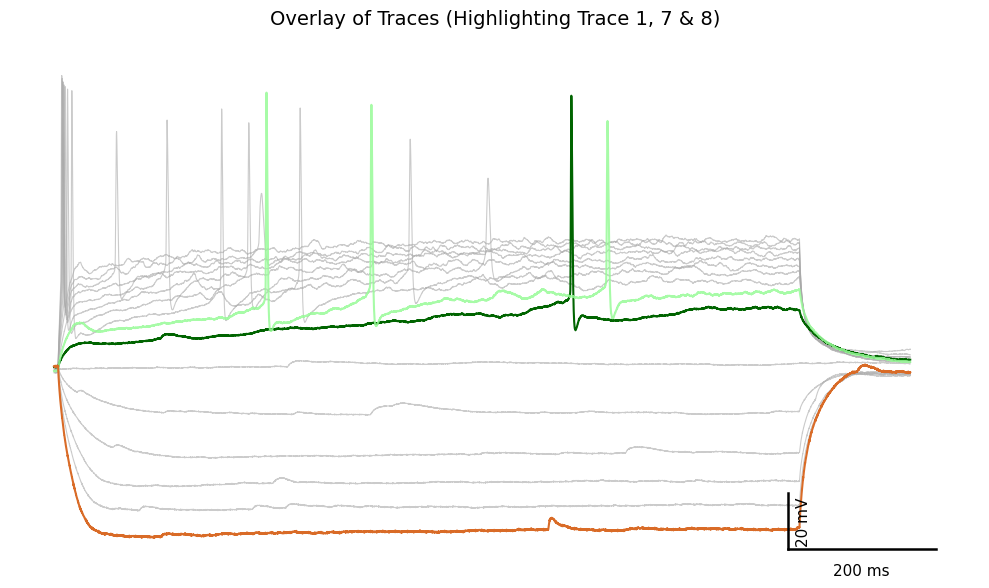

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 比例尺與單位參數設定
# ==========================================
SCALE_X_LEN = 200    # X軸比例尺長度 (ms)
SCALE_Y_LEN = 20     # Y軸比例尺長度 (mV)
X_UNIT = "ms"
Y_UNIT = "mV"

# 1. 讀取新的 Excel 檔案
file_path = "3815_transfer_traces.xlsx"
df = pd.read_excel(file_path, header=None)

# 2. 自動尋找純數字開始的列
start_row = 0
for i in range(len(df)):
    try:
        val = float(df.iloc[i, 0])
        if not np.isnan(val):
            start_row = i
            break
    except (ValueError, TypeError):
        continue

print(f"🔍 自動偵測：真正的電生理數據從第 {start_row + 1} 行開始。")

# 3. 切割出純數據，並強制轉為 float 類型
clean_data = df.iloc[start_row:].copy()
clean_data = clean_data.apply(pd.to_numeric, errors='coerce')
clean_data = clean_data.dropna(subset=[clean_data.columns[0]]).reset_index(drop=True)

# 4. 定義 Time 與 Traces
time = clean_data.iloc[:, 0]
traces = clean_data.iloc[:, 1:17]

print(f"📊 資料清洗完畢！時間點共 {len(time)} 筆，成功偵測到 {traces.shape[1]} 條 Traces。")

# ====================================================
# 繪圖：隱藏傳統 X/Y 軸，改用右下角 L 型比例尺
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(traces.columns):
    trace_num = i + 1  # 轉為人類直覺的 1~16

    if trace_num == 1:
        # Trace 1: 琥珀深橘色，突顯 Rebound Spike
        ax.plot(time, traces[col], color='#D96B27', alpha=1.0, linewidth=1.5, zorder=4)
    elif trace_num == 7:
        # Trace 7: 森林深綠色
        ax.plot(time, traces[col], color='#006400', alpha=1.0, linewidth=1.5, zorder=3)
    elif trace_num == 8:
        # Trace 8: 薄荷淺綠色
        ax.plot(time, traces[col], color='#98FB98', alpha=0.85, linewidth=1.5, zorder=3)
    else:
        # 其他 Trace: 中灰色
        ax.plot(time, traces[col], color='#A9A9A9', alpha=0.6, linewidth=0.8, zorder=2)

# ----------------------------------------------------
# 💡 核心：關閉傳統座標軸，在右下角繪製 L 型比例尺
# ----------------------------------------------------
ax.axis('off')  # 拔掉所有外框、刻度與標籤

# 取得數據的最大、最小值來決定比例尺邊界
data_x_min, data_x_max = time.min(), time.max()
data_y_min, data_y_max = traces.min().min(), traces.max().max()

# 比例尺的原點
scale_origin_x = data_x_max - SCALE_X_LEN + (data_x_max - data_x_min) * 0.03
scale_origin_y = data_y_min - 4

# 畫 L 型比例尺的線條
ax.plot([scale_origin_x, scale_origin_x], [scale_origin_y, scale_origin_y + SCALE_Y_LEN], color='black', linewidth=1.8, solid_capstyle='projecting', zorder=5)
ax.plot([scale_origin_x, scale_origin_x + SCALE_X_LEN], [scale_origin_y, scale_origin_y], color='black', linewidth=1.8, solid_capstyle='projecting', zorder=5)

# 加上比例尺的文字標籤
ax.text(scale_origin_x + (data_x_max - data_x_min) * 0.01, scale_origin_y + SCALE_Y_LEN / 2, f'{SCALE_Y_LEN} {Y_UNIT}', va='center', ha='left', fontsize=11, rotation=90, zorder=5)
ax.text(scale_origin_x + SCALE_X_LEN / 2, scale_origin_y - (data_y_max - data_y_min) * 0.03, f'{SCALE_X_LEN} {X_UNIT}', va='top', ha='center', fontsize=11, zorder=5)

# 設定標題與緊湊排版
ax.set_title('Overlay of Traces (Highlighting Trace 1, 7 & 8)', fontsize=14, pad=20)
plt.tight_layout()

# ====================================================
# 💾 匯出高畫質圖片 (簡化單行寫法，防止複製不完整)
# ====================================================
plt.savefig('electrophysiology_traces_3815.png', bbox_inches='tight', dpi=300, transparent=False, facecolor='white')

print("🎉 新圖表已成功生成與儲存！")
plt.show()

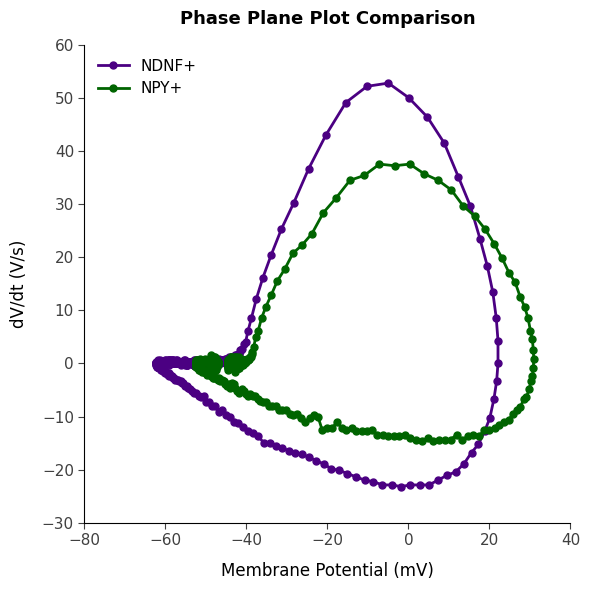

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 建立高效率讀取與清洗數據的函式
def load_ppp(path):
    df = pd.read_excel(path, header=None)
    for start_row in range(len(df)):
        try:
            if not np.isnan(float(df.iloc[start_row, 0])): break
        except: continue
    clean = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[0, 1]).reset_index(drop=True)
    return clean.iloc[:, 0].to_numpy(), clean.iloc[:, 1].to_numpy()

# 2. 載入兩組數據
v1, dv1 = load_ppp("/content/sample_data/4531_PPP.xlsx")  # NDNF+ (深紫色)
v2, dv2 = load_ppp("/content/3815_PPP.xlsx")              # NPY+ (深綠色)

# 3. 繪圖與設定
fig, ax = plt.subplots(figsize=(6, 6)) # 正方形比例在 PPP 圖中最美觀

# 畫出兩條帶點的曲線 (zorder 確保重疊時的層次)
ax.plot(v1, dv1, color='#4B0082', linestyle='-', linewidth=2, marker='o', markersize=5, label='NDNF+', zorder=3)
ax.plot(v2, dv2, color='#006400', linestyle='-', linewidth=2, marker='o', markersize=5, label='NPY+', zorder=4)

# 關閉網格與調整 L 型學術外框
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 設定坐標軸與刻度範圍
ax.set_xlim(-80, 40)
ax.set_ylim(-30, 60)
ax.set_xticks(np.arange(-80, 41, 20))
ax.set_yticks(np.arange(-30, 61, 10))
ax.tick_params(labelsize=11, colors='#404040', direction='out', length=4)

# 設定標籤、標題與圖例
ax.set_xlabel('Membrane Potential (mV)', fontsize=12, labelpad=10)
ax.set_ylabel('dV/dt (V/s)', fontsize=12, labelpad=10)
ax.set_title('Phase Plane Plot Comparison', fontsize=13, pad=15, fontweight='bold')
ax.set_facecolor('white')

# 💡 加入圖例 (frameon=False 拔掉圖例框線，符合頂級期刊規範)
ax.legend(loc='upper left', fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('ppp_comparison.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

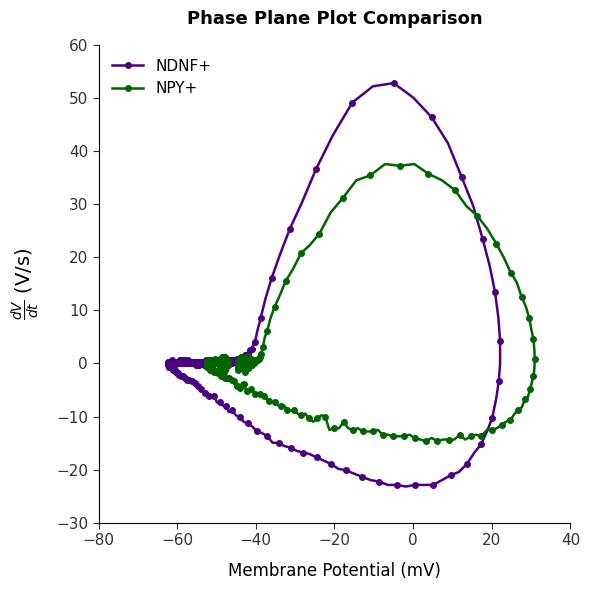

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 數據讀取與清洗函式
def load_ppp(path):
    df = pd.read_excel(path, header=None)
    for start_row in range(len(df)):
        try:
            if not np.isnan(float(df.iloc[start_row, 0])): break
        except: continue
    clean = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[0, 1]).reset_index(drop=True)
    return clean.iloc[:, 0].to_numpy(), clean.iloc[:, 1].to_numpy()

v1, dv1 = load_ppp("/content/sample_data/4531_PPP.xlsx")  # NDNF+
v2, dv2 = load_ppp("/content/3815_PPP.xlsx")              # NPY+

# 2. 建立完美期刊風圖表
fig, ax = plt.subplots(figsize=(6, 6))

# 💡 使用 markevery=2 稀釋過密的點點，並優化 markersize
ax.plot(v1, dv1, color='#4B0082', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NDNF+', zorder=3)
ax.plot(v2, dv2, color='#006400', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NPY+', zorder=4)

# 3. 移除網格與傳統上/右外框
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. 座標軸範圍與刻度對齊
ax.set_xlim(-80, 40)
ax.set_ylim(-30, 60)
ax.set_xticks(np.arange(-80, 41, 20))
ax.set_yticks(np.arange(-30, 61, 10))
ax.tick_params(labelsize=11, colors='#333333', direction='out', length=4)

# 5. 💡 高級學術標籤：X軸字體微調，Y軸改用 LaTeX 微分公式
ax.set_xlabel('Membrane Potential (mV)', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\frac{dV}{dt}\ \mathrm{(V/s)}$', fontsize=14, labelpad=10) # 👈 LaTeX 數學格式
ax.set_title('Phase Plane Plot Comparison', fontsize=13, pad=15, fontweight='bold')
ax.set_facecolor('white')

# 6. 💡 完美圖例：無框線極簡風
ax.legend(loc='upper left', fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('ppp_perfect_publication.png', bbox_inches='tight', dpi=600, facecolor='white') # 👈 提升到 600 DPI 印刷級畫質
plt.show()

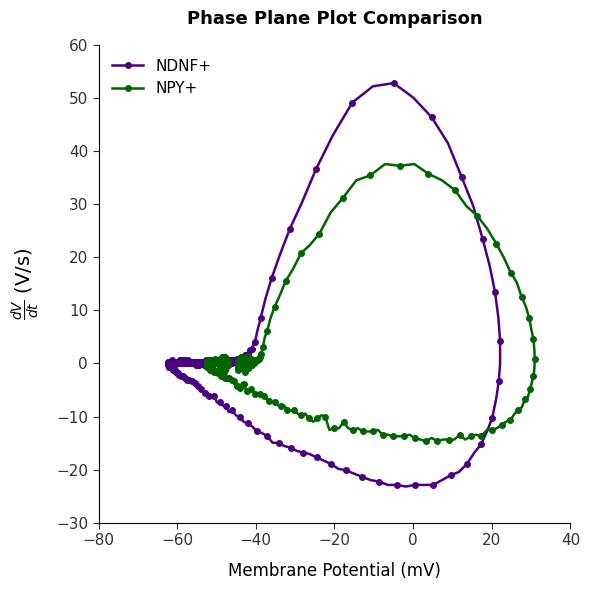

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 數據讀取與清洗函式
def load_ppp(path):
    df = pd.read_excel(path, header=None)
    for start_row in range(len(df)):
        try:
            if not np.isnan(float(df.iloc[start_row, 0])): break
        except: continue
    clean = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[0, 1]).reset_index(drop=True)
    return clean.iloc[:, 0].to_numpy(), clean.iloc[:, 1].to_numpy()

v1, dv1 = load_ppp("/content/sample_data/4531_PPP.xlsx")  # NDNF+
v2, dv2 = load_ppp("/content/3815_PPP.xlsx")              # NPY+

# 2. 建立完美期刊風圖表
fig, ax = plt.subplots(figsize=(6, 6))

# 💡 使用 markevery=2 稀釋過密的點點，並優化 markersize
ax.plot(v1, dv1, color='#4B0082', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NDNF+', zorder=3)
ax.plot(v2, dv2, color='#006400', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NPY+', zorder=4)

# 3. 移除網格與傳統上/右外框
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. 座標軸範圍與刻度對齊
ax.set_xlim(-80, 40)
ax.set_ylim(-30, 60)
ax.set_xticks(np.arange(-80, 41, 20))
ax.set_yticks(np.arange(-30, 61, 10))
ax.tick_params(labelsize=11, colors='#333333', direction='out', length=4)

# 5. 💡 高級學術標籤：X軸字體微調，Y軸改用 LaTeX 微分公式
ax.set_xlabel('Membrane Potential (mV)', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\frac{dV}{dt}\ \mathrm{(V/s)}$', fontsize=14, labelpad=10) # 👈 LaTeX 數學格式
ax.set_title('Phase Plane Plot Comparison', fontsize=13, pad=15, fontweight='bold')
ax.set_facecolor('white')

# 6. 💡 完美圖例：無框線極簡風
ax.legend(loc='upper left', fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('ppp_perfect_publication.png', bbox_inches='tight', dpi=600, facecolor='white') # 👈 提升到 600 DPI 印刷級畫質
plt.show()

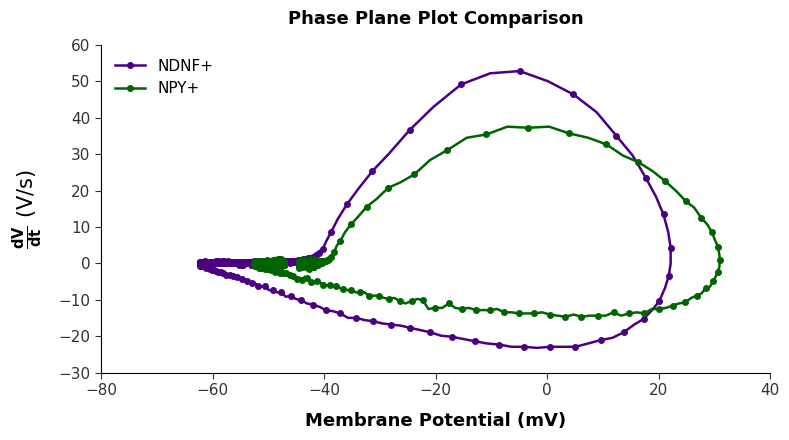

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 數據讀取與清洗函式
def load_ppp(path):
    df = pd.read_excel(path, header=None)
    for start_row in range(len(df)):
        try:
            if not np.isnan(float(df.iloc[start_row, 0])): break
        except: continue
    clean = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[0, 1]).reset_index(drop=True)
    return clean.iloc[:, 0].to_numpy(), clean.iloc[:, 1].to_numpy()

v1, dv1 = load_ppp("/content/sample_data/4531_PPP.xlsx")  # NDNF+
v2, dv2 = load_ppp("/content/3815_PPP.xlsx")              # NPY+

# 2. 建立完美期刊風圖表 💡 figsize 調整為 (8, 4.5) 完美微長比例
fig, ax = plt.subplots(figsize=(8, 4.5))

# 畫出兩條線，數據點抽樣維持 markevery=2
ax.plot(v1, dv1, color='#4B0082', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NDNF+', zorder=3)
ax.plot(v2, dv2, color='#006400', linestyle='-', linewidth=1.8, marker='o', markersize=4, markevery=2, label='NPY+', zorder=4)

# 3. 移除網格與傳統上/右外框
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. 座標軸範圍與刻度對齊
ax.set_xlim(-80, 40)
ax.set_ylim(-30, 60)
ax.set_xticks(np.arange(-80, 41, 20))
ax.set_yticks(np.arange(-30, 61, 10))
ax.tick_params(labelsize=11, colors='#333333', direction='out', length=4)

# 5. 💡 核心修正：X/Y軸標題加粗 (fontweight='bold') 並微調大小
ax.set_xlabel('Membrane Potential (mV)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\mathbf{\frac{dV}{dt}\ \mathrm{(V/s)}}$', fontsize=15, fontweight='bold', labelpad=10) # 👈 使用 mathbf 加粗 LaTeX
ax.set_title('Phase Plane Plot Comparison', fontsize=13, pad=15, fontweight='bold')
ax.set_facecolor('white')

# 6. 完美圖例：無框線極簡風
ax.legend(loc='upper left', fontsize=11, frameon=False)

plt.tight_layout()
# 匯出 600 DPI 印刷級圖片
plt.savefig('ppp_perfect_publication_bold.png', bbox_inches='tight', dpi=600, facecolor='white')
plt.show()

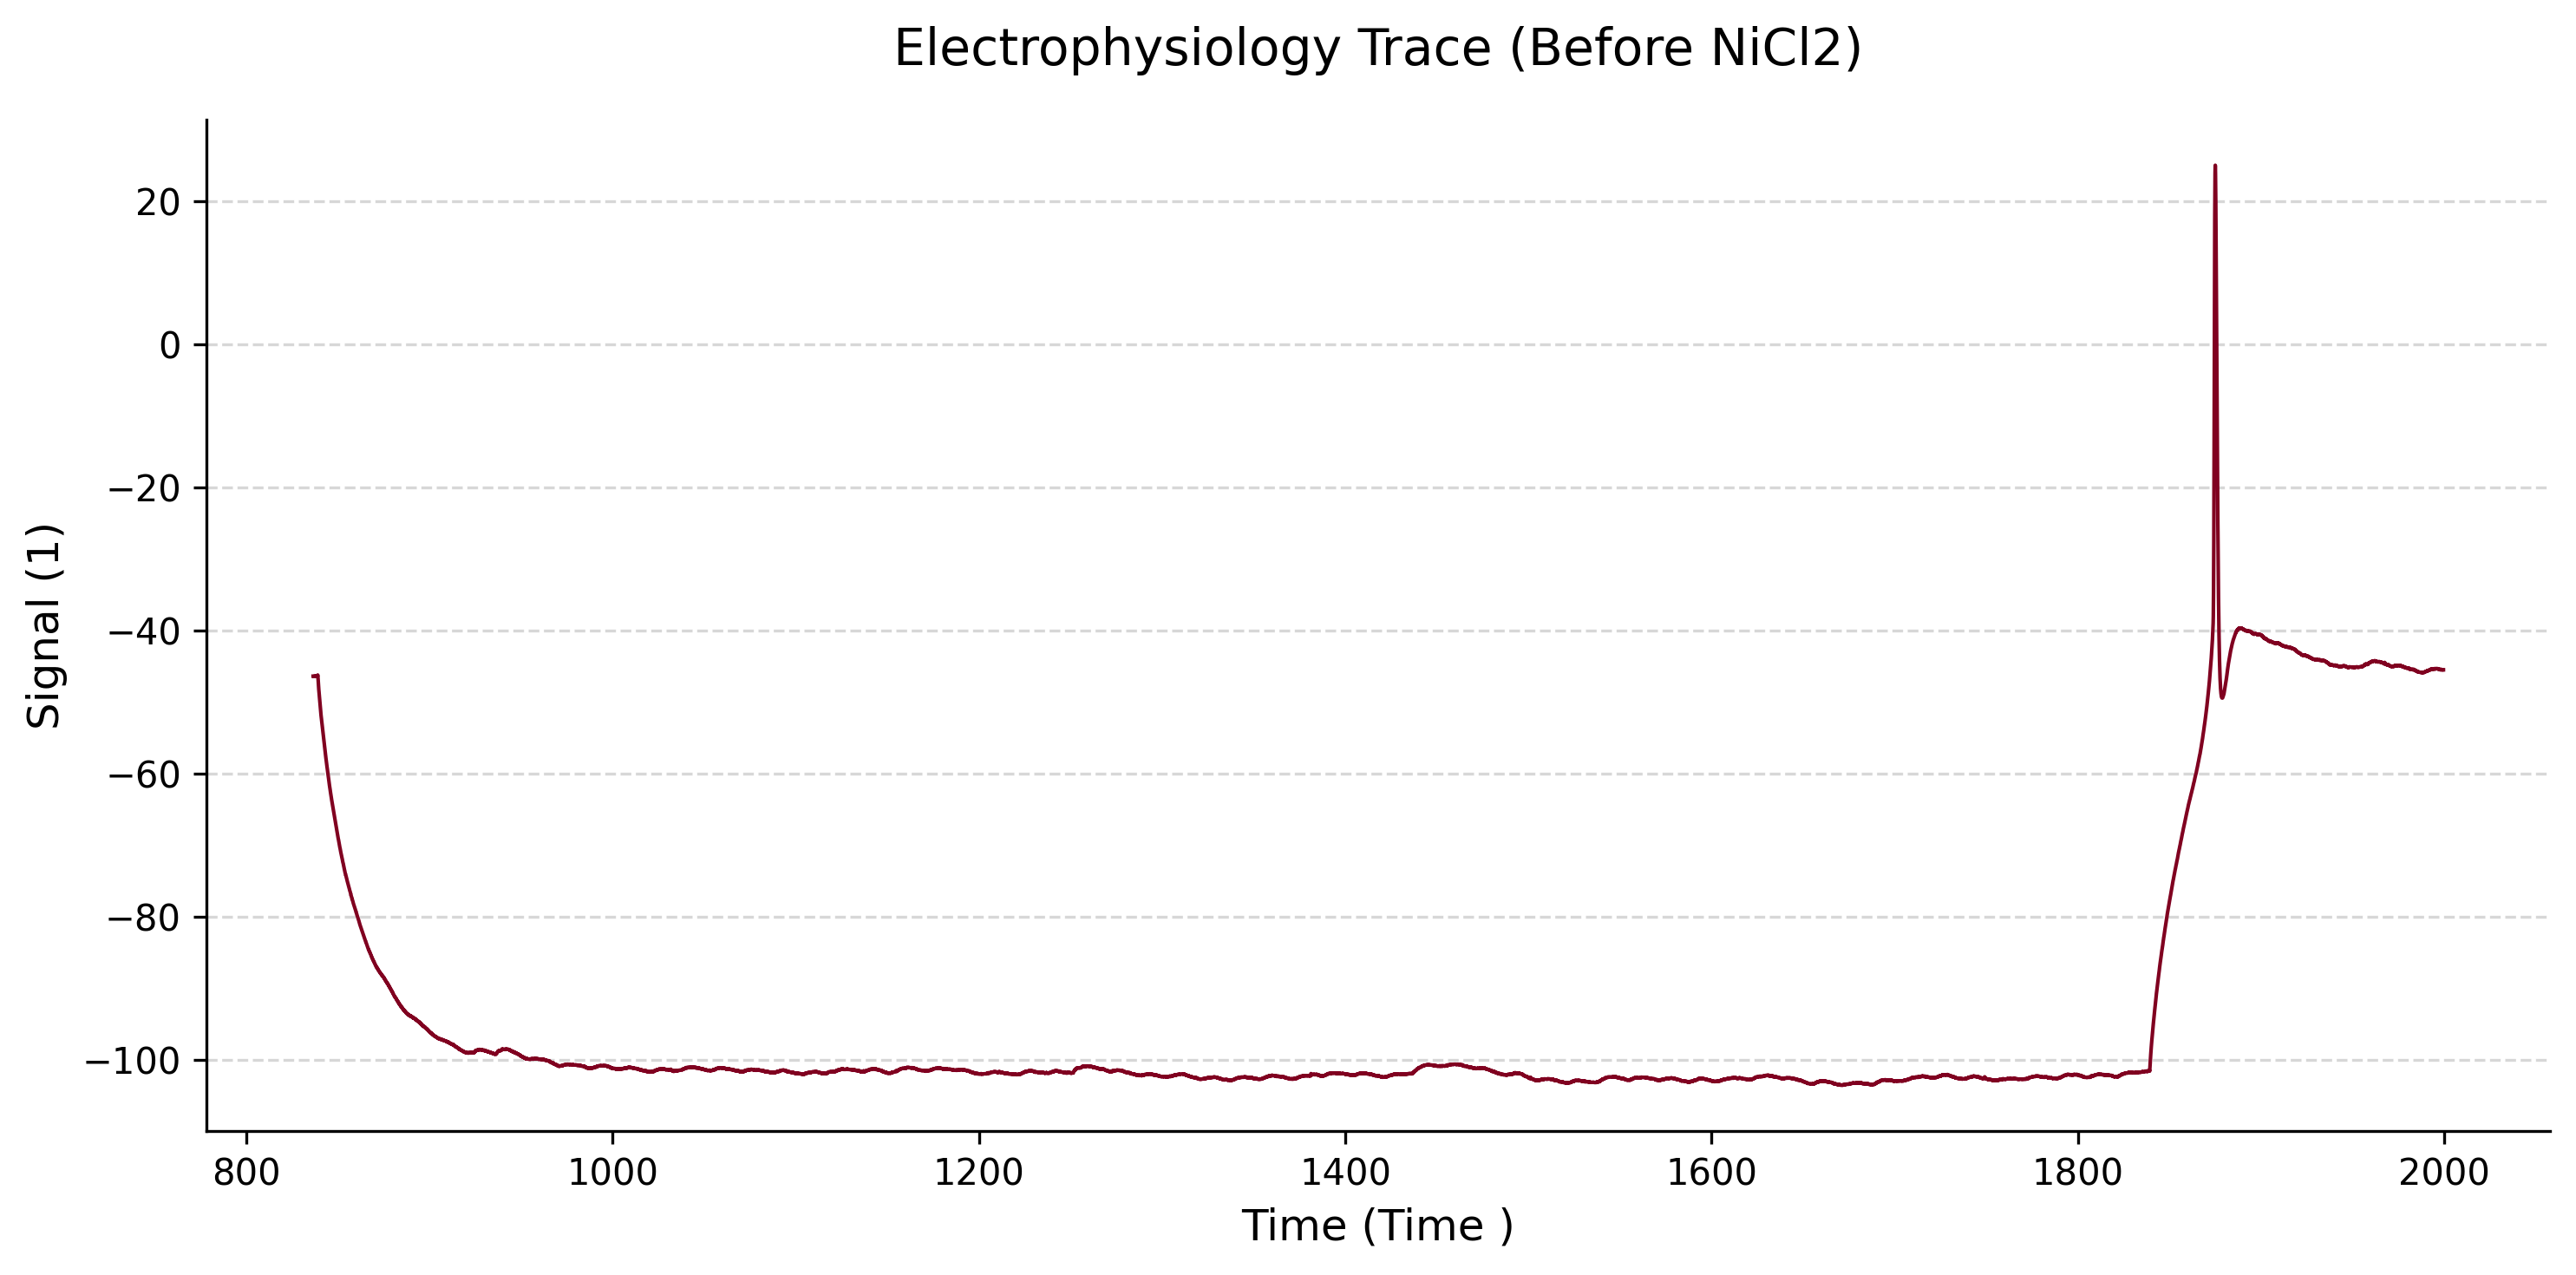

圖表已成功繪製並儲存至：/content/trace_plot.png


In [21]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. 讀取 Excel 檔案
file_path = "/content/4281_traces_before_NiCl.xlsx"

if not os.path.exists(file_path):
    print(f"找不到檔案：{file_path}，請確認檔案路徑是否正確。")
else:
    # 讀取 Excel，預設讀取第一個工作表 (Sheet)
    df = pd.read_excel(file_path)

    # 2. 定義資料行 (請根據你 Clampfit 匯出的實際欄位名稱調整)
    # 通常第一欄是時間 (Time)，第二欄是第一條 Trace (電流 Current 或 電壓 Voltage)
    time_col = df.columns[0]  # 第一欄：時間
    trace_col = df.columns[1]  # 第二欄：第一條 Trace

    # 3. 開始繪圖
    plt.figure(figsize=(10, 5), dpi=300)  # 設定高解析度適合學術論文/報告

    plt.plot(
        df[time_col],
        df[trace_col],
        color="#800020",
        linewidth=1,
        label="Trace 1",
    )

    # 4. 調整圖表美觀度 (符合學術期刊風格)
    plt.xlabel(f"Time ({time_col})", fontsize=12)
    plt.ylabel(f"Signal ({trace_col})", fontsize=12)
    plt.title("Electrophysiology Trace (Before NiCl2)", fontsize=14, pad=15)

    # 隱藏上方和右方的外框線 (Spines)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 調整刻度字型大小
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.grid(axis="y", linestyle="--", alpha=0.5)  # 僅開啟橫向虛線輔助
    plt.tight_layout()

    # 5. 儲存並顯示圖片
    output_image_path = "/content/trace_plot.png"
    plt.savefig(output_image_path, bbox_inches="tight")
    plt.show()

    print(f"圖表已成功繪製並儲存至：{output_image_path}")

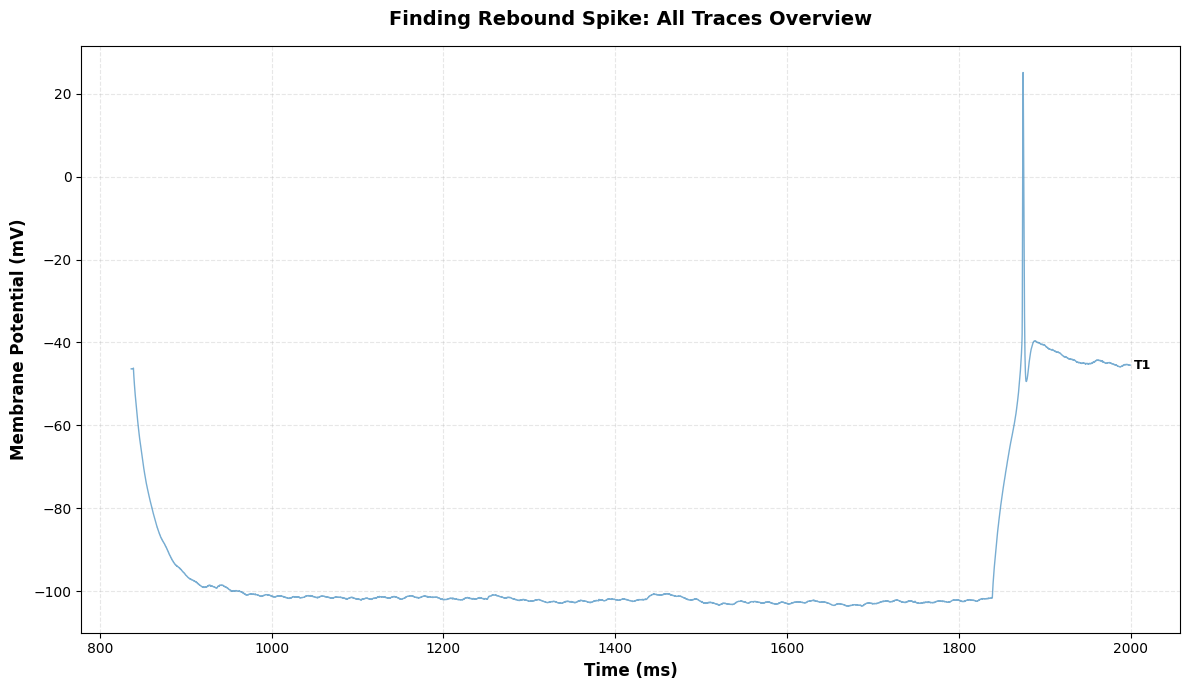

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取並清洗數據
file_path = "/content/4281_traces_before_NiCl.xlsx"
df = pd.read_excel(file_path, header=None)

for start_row in range(len(df)):
    try:
        if not np.isnan(float(df.iloc[start_row, 0])): break
    except: continue

clean_data = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[df.columns[0]]).reset_index(drop=True)
time = clean_data.iloc[:, 0]
traces_data = clean_data.iloc[:, 1:]

# 2. 建立全 Trace 檢視圖層
fig, ax = plt.subplots(figsize=(12, 7))

# 循環繪製每一條 Trace
for i, col in enumerate(traces_data.columns):
    trace_num = i + 1
    y_data = traces_data[col].to_numpy()

    # 畫出波形
    ax.plot(time, y_data, alpha=0.6, linewidth=1.0, label=f'Trace {trace_num}')

    # 在線條尾端標上 Trace 號碼，方便你識別
    ax.text(time.iloc[-1] + 5, y_data[-1], f'T{trace_num}',
            fontsize=9, va='center', ha='left', fontweight='bold')

# 設定圖表標籤
ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
ax.set_ylabel('Membrane Potential (mV)', fontsize=12, fontweight='bold')
ax.set_title('Finding Rebound Spike: All Traces Overview', fontsize=14, pad=15, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('find_rebound_spike_full.png', bbox_inches='tight', dpi=300)
plt.show()

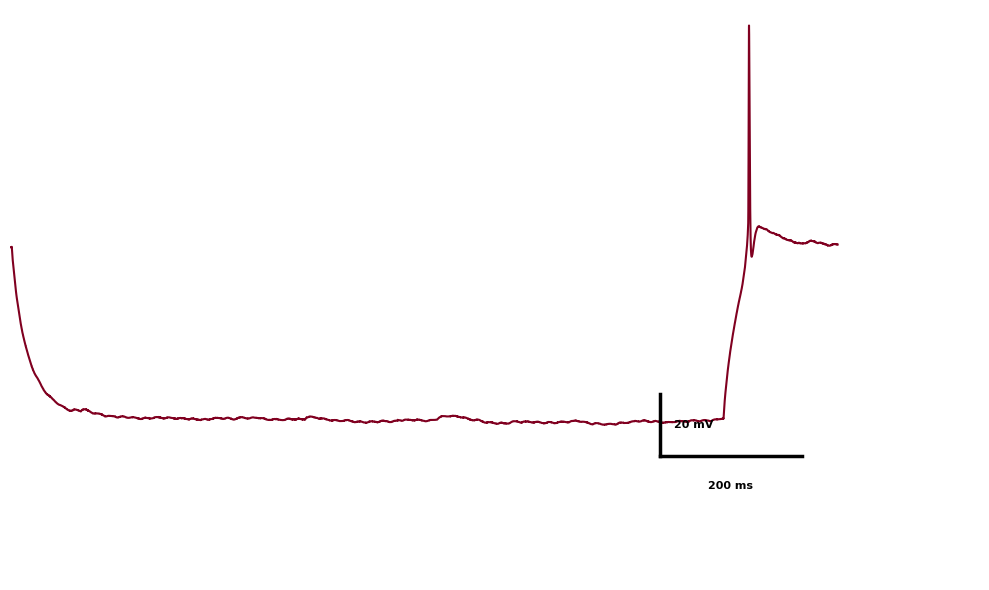

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取與數據定位
file_path = "/content/4281_traces_before_NiCl.xlsx"
df = pd.read_excel(file_path, header=None)

for start_row in range(len(df)):
    try:
        if not np.isnan(float(df.iloc[start_row, 0])): break
    except: continue

clean_data = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[df.columns[0]]).reset_index(drop=True)
time = clean_data.iloc[:, 0]

# 💡【手動選擇】如果你想看 Trace 7，這裡就設為 7 (代表 Excel 的第 8 欄)
# 索引從 0 開始，第 1 欄是 time，所以第 1 個 trace 在 index 1
target_trace_num = 1
col_index = target_trace_num

if col_index < clean_data.shape[1]:
    target_trace = clean_data.iloc[:, col_index]
else:
    print(f"警告：你選擇的 Trace {target_trace_num} 超出範圍，改為讀取第 1 個 Trace")
    target_trace = clean_data.iloc[:, 1]

# 2. 開始畫圖
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time, target_trace, color='#800020', linewidth=1.5, zorder=4)

# 3. 徹底拔掉背景與軸
ax.axis('off')

# 4. 繪製 L 型比例尺
ox = time.max() - 250
oy = target_trace.min() - 10

ax.plot([ox, ox], [oy, oy + 20], color='black', linewidth=2.5, zorder=5) # 20 mV
ax.plot([ox, ox + 200], [oy, oy], color='black', linewidth=2.5, zorder=5) # 200 ms

# 5. 加粗單位標籤
ax.text(ox + 20, oy + 10, '20 mV', va='center', ha='left', fontsize=8, fontweight='bold', zorder=6)
ax.text(ox + 100, oy - 8, '200 ms', va='top', ha='center', fontsize=8, fontweight='bold', zorder=6)

ax.set_xlim(time.min(), time.max() +200)
ax.set_ylim(target_trace.min() - 50, target_trace.max() + 5)

plt.tight_layout()
plt.savefig('fixed_trace_plot.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

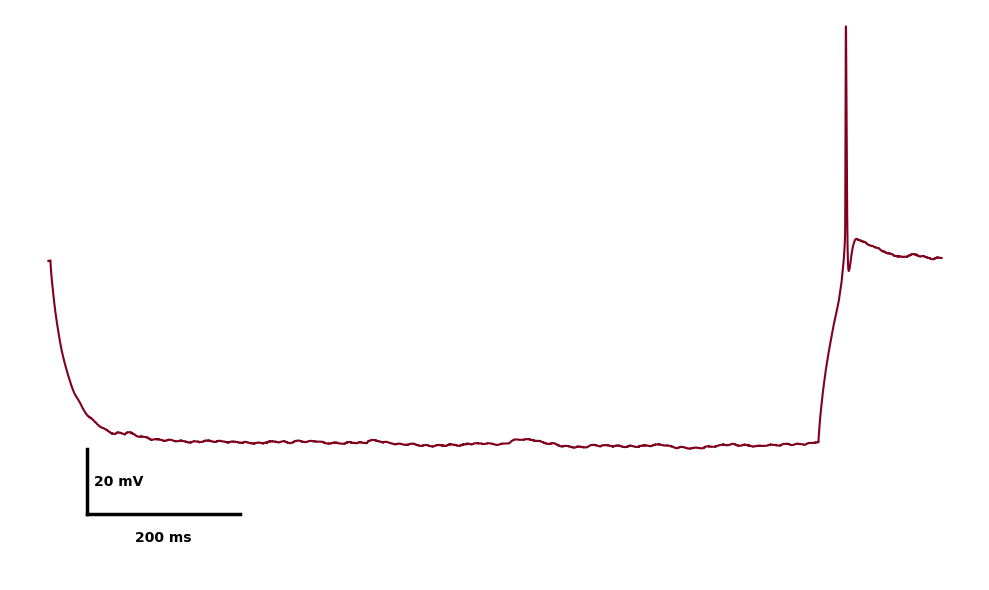

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取與數據定位
file_path = "/content/4281_traces_before_NiCl.xlsx"
df = pd.read_excel(file_path, header=None)

for start_row in range(len(df)):
    try:
        if not np.isnan(float(df.iloc[start_row, 0])): break
    except: continue

clean_data = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[df.columns[0]]).reset_index(drop=True)
time = clean_data.iloc[:, 0]

# 指定要繪製的 Trace 號碼 (這裡設為 1，你可以隨時調整)
col_index = 1
target_trace = clean_data.iloc[:, col_index]

# 2. 開始畫圖
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time, target_trace, color='#800020', linewidth=1.5, zorder=4)

# 3. 徹底拔掉背景與軸
ax.axis('off')

# ----------------------------------------------------
# 💡 核心修正：比例尺定位至「左下角」
# ----------------------------------------------------
# ox 設為時間起點，oy 設為數據最低點下方一段距離
ox = time.min() + 50
oy = target_trace.min() - 20

# 畫 L 型比例尺
ax.plot([ox, ox], [oy, oy + 20], color='black', linewidth=2.5, zorder=5) # 20 mV
ax.plot([ox, ox + 200], [oy, oy], color='black', linewidth=2.5, zorder=5) # 200 ms

# 加粗單位標籤
ax.text(ox + 10, oy + 10, '20 mV', va='center', ha='left', fontsize=10, fontweight='bold', zorder=6)
ax.text(ox + 100, oy - 5, '200 ms', va='top', ha='center', fontsize=10, fontweight='bold', zorder=6)

# 設定邊界，確保左下角有足夠空間放置卡尺
ax.set_xlim(time.min() - 50, time.max() + 50)
ax.set_ylim(oy - 20, target_trace.max() + 5)

plt.tight_layout()
plt.savefig('trace_bottom_left_scale.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

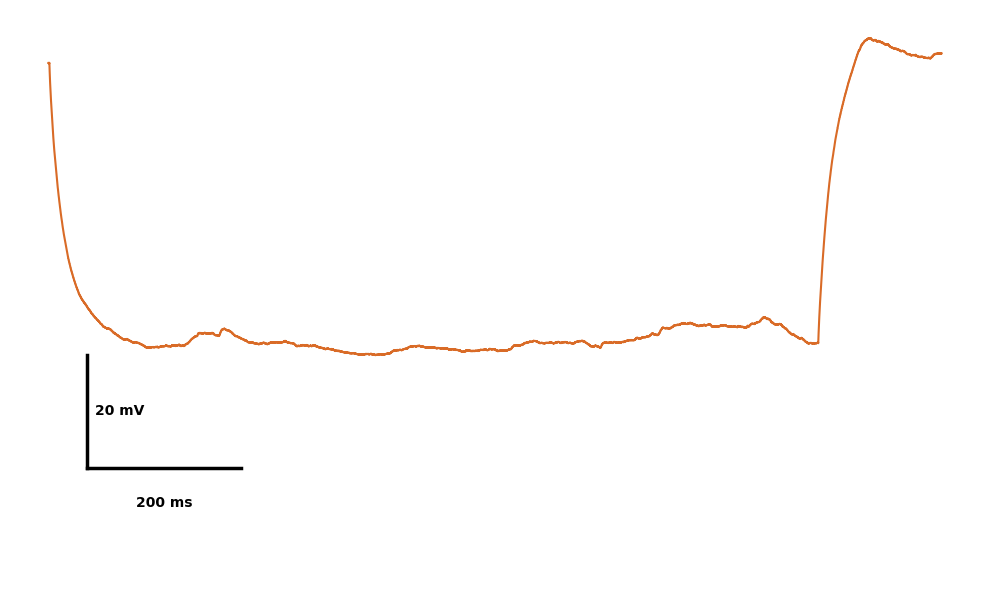

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取並處理數據
file_path = "/content/4284_traces_afterNicl.xlsx"
df = pd.read_excel(file_path, header=None)

for start_row in range(len(df)):
    try:
        if not np.isnan(float(df.iloc[start_row, 0])): break
    except: continue

clean_data = df.iloc[start_row:].apply(pd.to_numeric, errors='coerce').dropna(subset=[df.columns[0]]).reset_index(drop=True)
time = clean_data.iloc[:, 0]

# 指定要繪製的 Trace 號碼 (設為 1，如有需要請調整)
col_index = 1
target_trace = clean_data.iloc[:, col_index]

# 2. 開始畫圖
fig, ax = plt.subplots(figsize=(10, 6))
# 🎨 顏色更新為 #D96B27
ax.plot(time, target_trace, color='#D96B27', linewidth=1.5, zorder=4)

# 3. 拔掉座標軸
ax.axis('off')

# 4. 繪製左下角比例尺
ox = time.min() + 50
oy = target_trace.min() - 20

ax.plot([ox, ox], [oy, oy + 20], color='black', linewidth=2.5, zorder=5) # 20 mV
ax.plot([ox, ox + 200], [oy, oy], color='black', linewidth=2.5, zorder=5) # 200 ms

# 加粗單位標籤
ax.text(ox + 10, oy + 10, '20 mV', va='center', ha='left', fontsize=10, fontweight='bold', zorder=6)
ax.text(ox + 100, oy - 5, '200 ms', va='top', ha='center', fontsize=10, fontweight='bold', zorder=6)

# 設定留白
ax.set_xlim(time.min() - 50, time.max() + 50)
ax.set_ylim(oy - 20, target_trace.max() + 5)

plt.tight_layout()
plt.savefig('trace_after_NiCl_orange.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()